# Analytics - Camada Silver

Análises com dados limpos e enriquecidos da camada silver

## Configuração Inicial

### Importação de Bibliotecas

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import psycopg2
from psycopg2 import sql

### Configuração do Banco de Dados

In [2]:
DB_NAME = "uber_analytics_silver"
DB_USER = "postgres"
DB_PASSWORD = "postgres"
DB_HOST = "localhost"
DB_PORT = "5432"

### Carregamento dos Dados

In [3]:
plt.style.use('seaborn-v0_8')
sns.set_theme(context="notebook", style="whitegrid")

conn = psycopg2.connect(
    host=DB_HOST,
    database=DB_NAME,
    user=DB_USER,
    password=DB_PASSWORD,
    port=DB_PORT
)

df = pd.read_sql("SELECT * FROM booking", conn)

print(f'Total de registros: {len(df)}')
print(f'Total de colunas: {len(df.columns)}')
print(f'Colunas: {list(df.columns)}')

/run/user/1000/app/org.jupyter.JupyterLab/ipykernel_5240/2732328982.py:12: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql("SELECT * FROM booking", conn)


Total de registros: 148767
Total de colunas: 27
Colunas: ['id', 'date', 'time', 'status', 'customer_id', 'vehicle', 'pickup', 'drop', 'pickup_zone', 'pickup_region', 'drop_zone', 'drop_region', 'vtat', 'ctat', 'cancelled_by_customer', 'reason_cancelled_by_customer', 'cancelled_by_driver', 'reason_cancelled_by_driver', 'incomplete', 'reason_incomplete', 'value', 'distance', 'distance_category', 'value_per_km', 'driver_rating', 'customer_rating', 'payment']


### Visão Geral dos Dados

In [4]:
print('Informações do Dataset:')
df.info()
print('\nEstatísticas Descritivas:')
df.describe()

Informações do Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148767 entries, 0 to 148766
Data columns (total 27 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   id                            148767 non-null  object 
 1   date                          148767 non-null  object 
 2   time                          148767 non-null  object 
 3   status                        148767 non-null  object 
 4   customer_id                   148767 non-null  object 
 5   vehicle                       148767 non-null  object 
 6   pickup                        148767 non-null  object 
 7   drop                          148767 non-null  object 
 8   pickup_zone                   148767 non-null  object 
 9   pickup_region                 148767 non-null  object 
 10  drop_zone                     148767 non-null  object 
 11  drop_region                   148767 non-null  object 
 12  vtat                

,vtat,ctat,value,distance,value_per_km,driver_rating,customer_rating
count,138366.000000,101175.000000,101175.000000,101175.000000,92248.000000,92248.000000,92248.000000
mean,8.454819,29.150249,508.290230,24.640956,33.849226,4.230756,4.404301
std,3.773341,8.901703,395.913208,14.002172,54.123118,0.436741,0.437908
min,2.000000,10.000000,50.000000,1.000000,1.010000,3.000000,3.000000
25%,5.300000,21.600000,234.000000,12.460000,8.980000,4.100000,4.200000
50%,8.300000,28.800000,414.000000,23.720000,17.700000,4.300000,4.500000
75%,11.300000,36.800000,689.000000,36.820000,35.580000,4.600000,4.800000
max,20.000000,45.000000,4277.000000,50.000000,1666.990000,5.000000,5.000000


## Análises Geográficas

### Distribuição de Viagens por Zona

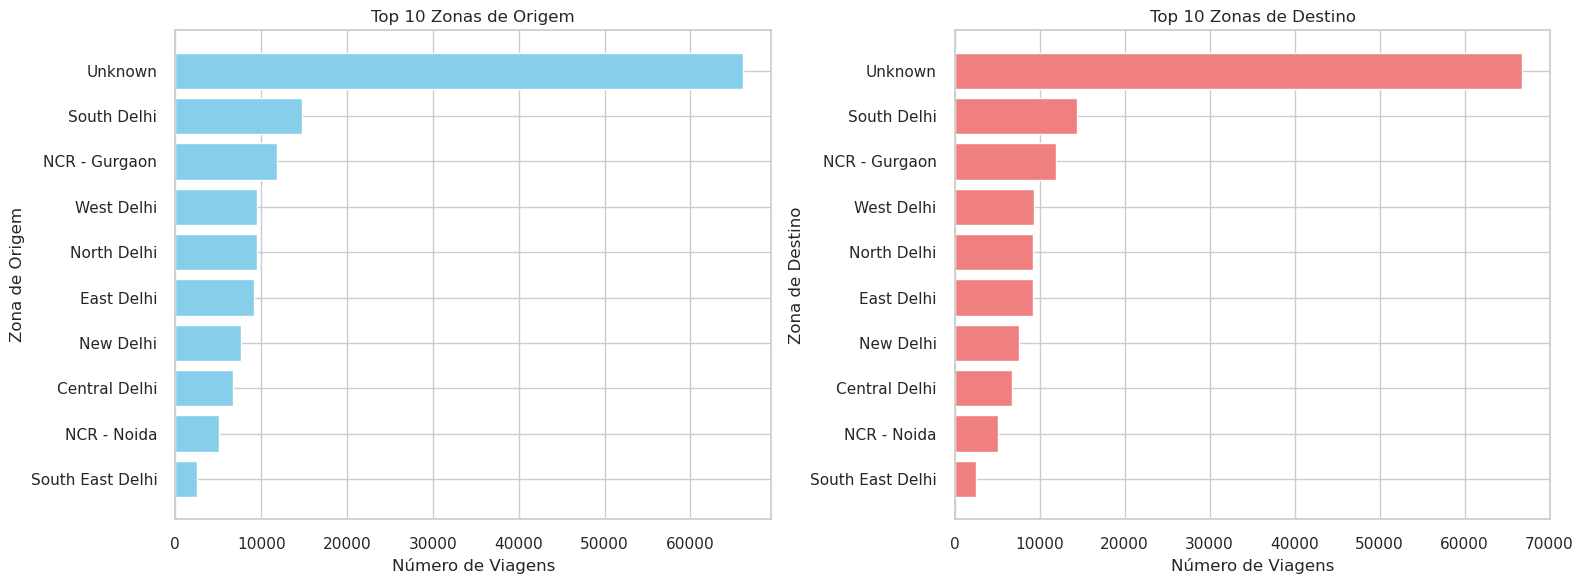

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

pickup_zone_counts = df['pickup_zone'].value_counts().head(10)
axes[0].barh(pickup_zone_counts.index, pickup_zone_counts.values, color='skyblue')
axes[0].set_xlabel('Número de Viagens')
axes[0].set_ylabel('Zona de Origem')
axes[0].set_title('Top 10 Zonas de Origem')
axes[0].invert_yaxis()

drop_zone_counts = df['drop_zone'].value_counts().head(10)
axes[1].barh(drop_zone_counts.index, drop_zone_counts.values, color='lightcoral')
axes[1].set_xlabel('Número de Viagens')
axes[1].set_ylabel('Zona de Destino')
axes[1].set_title('Top 10 Zonas de Destino')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

In [6]:
zone_stats = df.groupby('pickup_zone').agg({
    'id': 'count',
    'value': 'mean',
    'distance': 'mean'
}).round(2)

zone_stats.columns = ['Total Viagens', 'Receita Média', 'Distância Média']
zone_stats = zone_stats.sort_values('Total Viagens', ascending=False)
zone_stats.head(10)

,Total Viagens,Receita Média,Distância Média
pickup_zone,,,
Unknown,66105,507.34,24.69
South Delhi,14730,505.26,24.61
NCR - Gurgaon,11854,513.21,24.57
West Delhi,9543,510.73,24.73
North Delhi,9494,505.85,24.79
East Delhi,9199,513.75,24.84
New Delhi,7645,507.15,24.42
Central Delhi,6744,502.71,24.38
NCR - Noida,5028,522.83,24.41


A receita média está indicada em rúpias indianas, e a distância em km. O gráfico acima nos mostra o número de viagens por zona, podemos ver que muitas localidades acabaram ficando por unknown, mas que tirando essas, a zona com mais corridas é South Delhi.

### Análise de Regiões

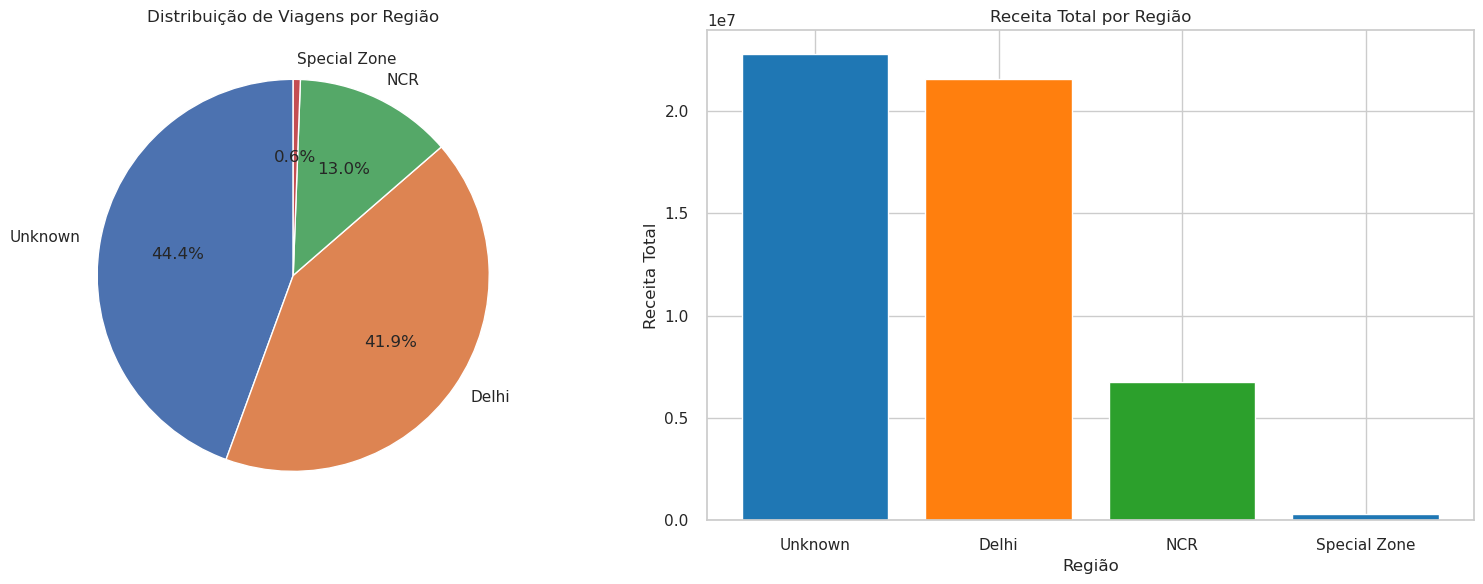

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

region_counts = df['pickup_region'].value_counts()
axes[0].pie(region_counts.values, labels=region_counts.index, autopct='%1.1f%%', startangle=90)
axes[0].set_title('Distribuição de Viagens por Região')

region_revenue = df.groupby('pickup_region')['value'].sum().sort_values(ascending=False)
axes[1].bar(region_revenue.index, region_revenue.values, color=['#1f77b4', '#ff7f0e', '#2ca02c']), axes[1].set_xlabel('Região')
axes[1].set_ylabel('Receita Total')
axes[1].set_title('Receita Total por Região')

plt.tight_layout()
plt.show()

In [8]:
region_stats = df.groupby('pickup_region').agg({
    'id': 'count',
    'value': ['mean', 'sum'],
    'distance': 'mean',
    'driver_rating': 'mean'
}).round(2)

region_stats.columns = ['Total Viagens', 'Receita Média', 'Receita Total', 'Distância Média', 'Avaliação Média']
region_stats

,Total Viagens,Receita Média,Receita Total,Distância Média,Avaliação Média
pickup_region,,,,,
Delhi,62386,507.83,21552848.0,24.61,4.23
NCR,19404,513.81,6771529.0,24.54,4.23
Special Zone,872,490.81,293507.0,24.88,4.22
Unknown,66105,507.34,22808380.0,24.69,4.23


Notamos que, ignorando as regiões que acabaram por unknown, a região com maior receita é Delhi, consistindo de ~42% da receita anual da cidade.

### Rotas Mais Populares

In [9]:
df_completed = df[df['status'] == 'Completed'].copy()

df_completed['route'] = df_completed['pickup_zone'] + ' → ' + df_completed['drop_zone']

route_stats = df_completed.groupby('route').agg({
    'id': 'count',
    'value': 'mean',
    'distance': 'mean'
}).round(2)

route_stats.columns = ['Total Viagens', 'Receita Média', 'Distância Média']
route_stats = route_stats.sort_values('Total Viagens', ascending=False)

print('Top 20 Rotas Mais Populares:')
route_stats.head(20)

Top 20 Rotas Mais Populares:


,Total Viagens,Receita Média,Distância Média
route,,,
Unknown → Unknown,18390,510.90,26.11
South Delhi → Unknown,4122,499.65,26.07
Unknown → South Delhi,3937,506.63,25.81
NCR - Gurgaon → Unknown,3281,516.20,25.98
Unknown → NCR - Gurgaon,3274,500.31,25.89
North Delhi → Unknown,2703,506.90,25.72
West Delhi → Unknown,2646,515.32,25.93
Unknown → West Delhi,2624,504.48,26.25
Unknown → East Delhi,2583,501.42,26.25


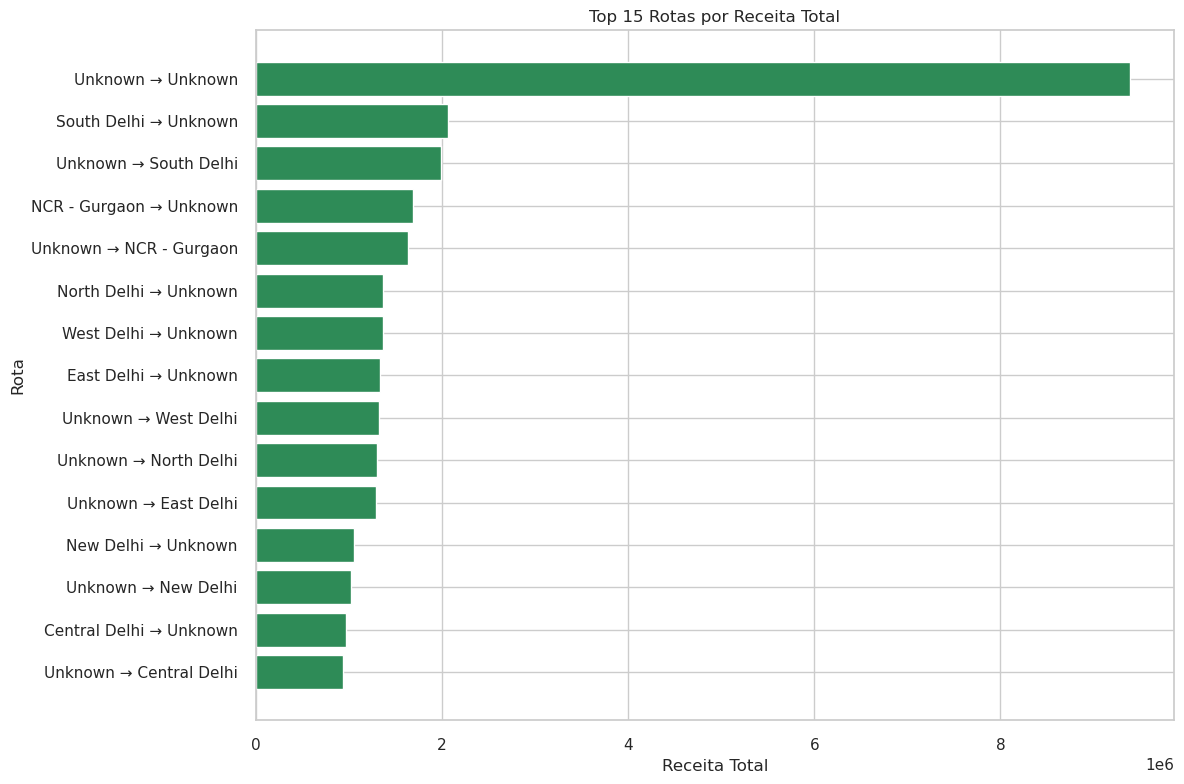

In [10]:
route_revenue = df_completed.groupby('route')['value'].sum().sort_values(ascending=False).head(15)

plt.figure(figsize=(12, 8))
plt.barh(range(len(route_revenue)), route_revenue.values, color='seagreen')
plt.yticks(range(len(route_revenue)), route_revenue.index)
plt.xlabel('Receita Total')
plt.ylabel('Rota')
plt.title('Top 15 Rotas por Receita Total')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

O gráfico acima acabou muito prejudicado pela região desconhecida gerada na transformação dos dados.

### Fluxo entre Regiões

In [11]:
df_completed['region_flow'] = df_completed['pickup_region'] + ' → ' + df_completed['drop_region']

flow_stats = df_completed.groupby('region_flow').agg({
    'id': 'count',
    'value': 'mean',
    'distance': 'mean'
}).round(2)

flow_stats.columns = ['Total Viagens', 'Receita Média', 'Distância Média']
flow_stats = flow_stats.sort_values('Total Viagens', ascending=False)

print('Fluxo de Viagens entre Regiões:')
flow_stats

Fluxo de Viagens entre Regiões:


,Total Viagens,Receita Média,Distância Média
region_flow,,,
Unknown → Unknown,18390,510.90,26.11
Delhi → Unknown,17378,508.69,25.94
Unknown → Delhi,16930,506.21,26.11
Delhi → Delhi,15962,508.09,26.11
Unknown → NCR,5418,499.34,25.83
NCR → Unknown,5389,521.02,25.89
Delhi → NCR,5139,498.66,25.75
NCR → Delhi,5069,506.25,25.89
NCR → NCR,1527,526.30,25.62


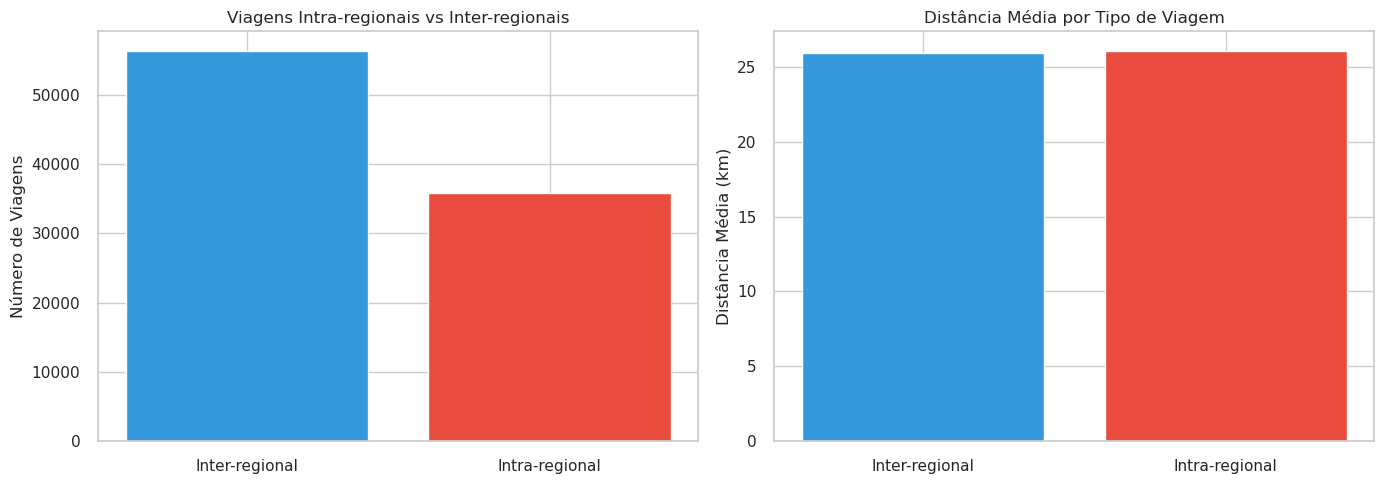


Estatísticas por Tipo de Viagem:


,Total Viagens,Receita Média,Distância Média
trip_type,,,
Inter-regional,56369,506.84,25.95
Intra-regional,35879,510.30,26.09


In [12]:
df_completed['trip_type'] = df_completed.apply(
    lambda x: 'Intra-regional' if x['pickup_region'] == x['drop_region'] else 'Inter-regional',
    axis=1
)

trip_type_stats = df_completed.groupby('trip_type').agg({
    'id': 'count',
    'value': 'mean',
    'distance': 'mean'
}).round(2)

trip_type_stats.columns = ['Total Viagens', 'Receita Média', 'Distância Média']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(trip_type_stats.index, trip_type_stats['Total Viagens'], color=['#3498db', '#e74c3c']), axes[0].set_ylabel('Número de Viagens')
axes[0].set_title('Viagens Intra-regionais vs Inter-regionais')

axes[1].bar(trip_type_stats.index, trip_type_stats['Distância Média'], color=['#3498db', '#e74c3c']), axes[1].set_ylabel('Distância Média (km)')
axes[1].set_title('Distância Média por Tipo de Viagem')

plt.tight_layout()
plt.show()

print('\nEstatísticas por Tipo de Viagem:')
trip_type_stats

Podemos ver que a maior parte das corridas acaba por ser entre regiões da cidade, mas curiosamente a distância média fica muito parecida, indicando regiões provavelmente muito largas que contam com um fluxo interno muito longo.

## Análises de Distância

### Distribuição por Categoria de Distância

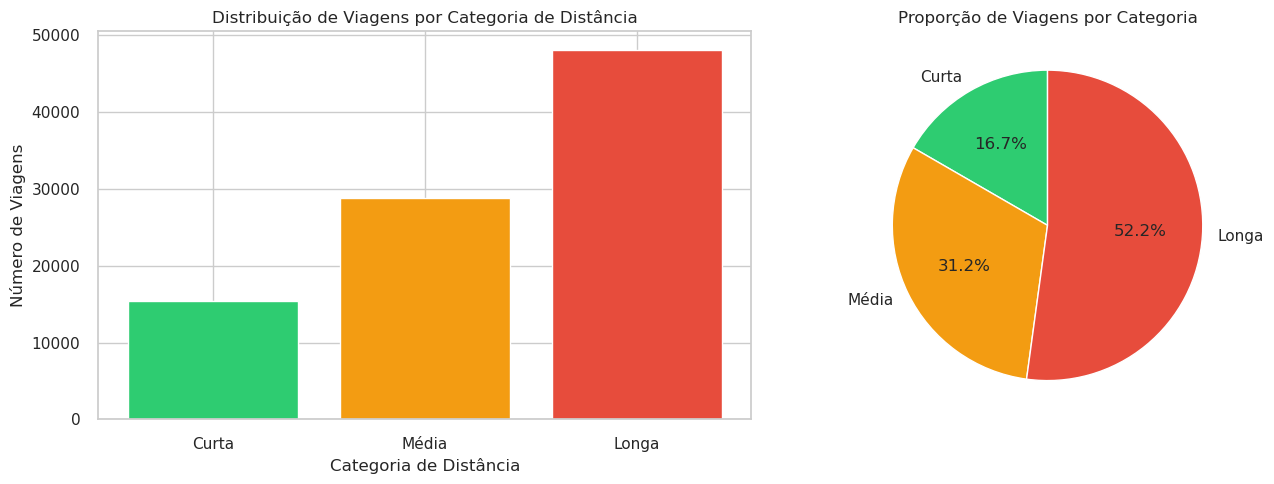

In [13]:
category_order = ['Curta', 'Média', 'Longa']
df_completed['distance_category'] = pd.Categorical(
    df_completed['distance_category'],
    categories=category_order,
    ordered=True
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

category_counts = df_completed['distance_category'].value_counts().reindex(category_order)
axes[0].bar(category_counts.index, category_counts.values, color=['#2ecc71', '#f39c12', '#e74c3c']), axes[0].set_xlabel('Categoria de Distância')
axes[0].set_ylabel('Número de Viagens')
axes[0].set_title('Distribuição de Viagens por Categoria de Distância')

axes[1].pie(category_counts.values, labels=category_counts.index, autopct='%1.1f%%', 
            colors=['#2ecc71', '#f39c12', '#e74c3c'], startangle=90), axes[1].set_title('Proporção de Viagens por Categoria')

plt.tight_layout()
plt.show()

In [14]:
category_stats = df_completed.groupby('distance_category').agg({
    'id': 'count',
    'value': 'mean',
    'distance': 'mean',
    'driver_rating': 'mean'
}).round(2)

category_stats.columns = ['Total Viagens', 'Receita Média', 'Distância Média', 'Avaliação Média']

print('Estatísticas por Categoria de Distância:')
category_stats

Estatísticas por Categoria de Distância:


/run/user/1000/app/org.jupyter.JupyterLab/ipykernel_5240/539071710.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  category_stats = df_completed.groupby('distance_category').agg({


,Total Viagens,Receita Média,Distância Média,Avaliação Média
distance_category,,,,
Curta,15373,503.43,6.02,4.23
Média,28761,508.69,17.53,4.23
Longa,48114,509.41,37.46,4.23


O gráfico acima nos aponta que grande parte das corridas feitas na cidade se tratam de corridas longas, o que acentua a proposição anterior de que as regioes da cidade são extensas com pelo menos mais de 25km entre uma e outra.

### Análise de Rentabilidade (value_per_km)

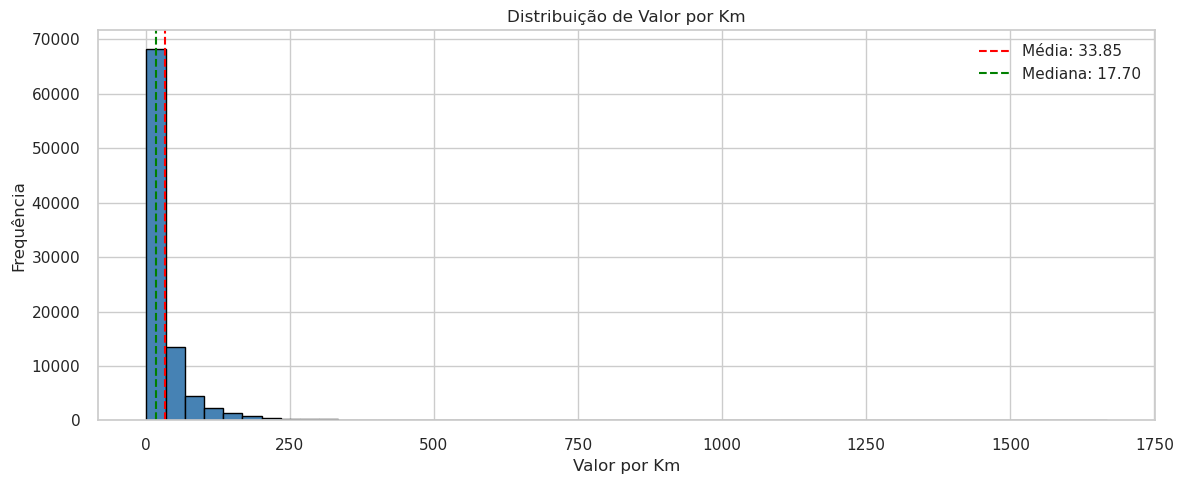

Estatísticas de Value per Km:
Média: 33.85
Mediana: 17.70
Desvio Padrão: 54.12


In [15]:
df_value_per_km = df_completed[df_completed['value_per_km'].notna()]

plt.figure(figsize=(12, 5))
plt.hist(df_value_per_km['value_per_km'], bins=50, color='steelblue', edgecolor='black')
plt.xlabel('Valor por Km')
plt.ylabel('Frequência')
plt.title('Distribuição de Valor por Km')
plt.axvline(df_value_per_km['value_per_km'].mean(), color='red', linestyle='--', 
            label=f'Média: {df_value_per_km["value_per_km"].mean():.2f}')
plt.axvline(df_value_per_km['value_per_km'].median(), color='green', linestyle='--', 
            label=f'Mediana: {df_value_per_km["value_per_km"].median():.2f}')
plt.legend()
plt.tight_layout()
plt.show()

print(f'Estatísticas de Value per Km:')
print(f'Média: {df_value_per_km["value_per_km"].mean():.2f}')
print(f'Mediana: {df_value_per_km["value_per_km"].median():.2f}')
print(f'Desvio Padrão: {df_value_per_km["value_per_km"].std():.2f}')

<Figure size 1000x600 with 0 Axes>

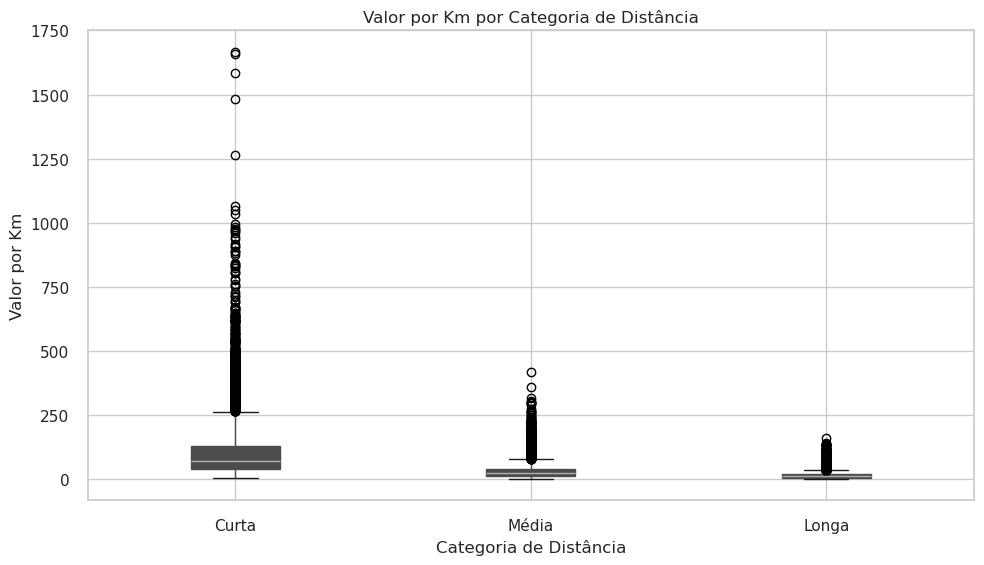

In [16]:
plt.figure(figsize=(10, 6))
df_value_per_km.boxplot(column='value_per_km', by='distance_category', 
                         figsize=(10, 6), patch_artist=True)
plt.suptitle('')
plt.xlabel('Categoria de Distância')
plt.ylabel('Valor por Km')
plt.title('Valor por Km por Categoria de Distância')
plt.tight_layout()
plt.show()

Aqui temos a comparação de valores por km em suas categorias de distância. Viagens com menos de 10km possuem a maior variação, algumas bem acima do padrão inicial e da média apresentada no gráfico de rentabilidade anterior.

In [17]:
route_value_per_km = df_value_per_km.groupby('route').agg({
    'id': 'count',
    'value_per_km': 'mean',
    'value': 'sum'
}).round(2)

route_value_per_km.columns = ['Total Viagens', 'Value per Km Médio', 'Receita Total']
route_value_per_km = route_value_per_km[route_value_per_km['Total Viagens'] >= 10]
route_value_per_km = route_value_per_km.sort_values('Value per Km Médio', ascending=False)

print('Top 20 Rotas Mais Rentáveis (mínimo 10 viagens):')
route_value_per_km.head(20)

Top 20 Rotas Mais Rentáveis (mínimo 10 viagens):


,Total Viagens,Value per Km Médio,Receita Total
route,,,
Central Delhi → NCR - Faridabad,23,78.08,13616.0
South Delhi → South West Delhi,46,67.82,31189.0
Airport Zone → NCR - Gurgaon,37,61.27,21362.0
West Delhi → North East Delhi,69,60.06,41958.0
NCR - Panipat → South East Delhi,12,54.98,7960.0
North East Delhi → NCR - Gurgaon,78,51.57,43217.0
NCR - Faridabad → North Delhi,43,50.73,23881.0
New Delhi → Airport Zone,21,49.31,10456.0
South East Delhi → South East Delhi,20,48.97,9979.0


### Distância vs Categoria de Veículo

/run/user/1000/app/org.jupyter.JupyterLab/ipykernel_5240/3776377450.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  vehicle_distance = df_completed.groupby(['vehicle', 'distance_category']).size().unstack(fill_value=0)


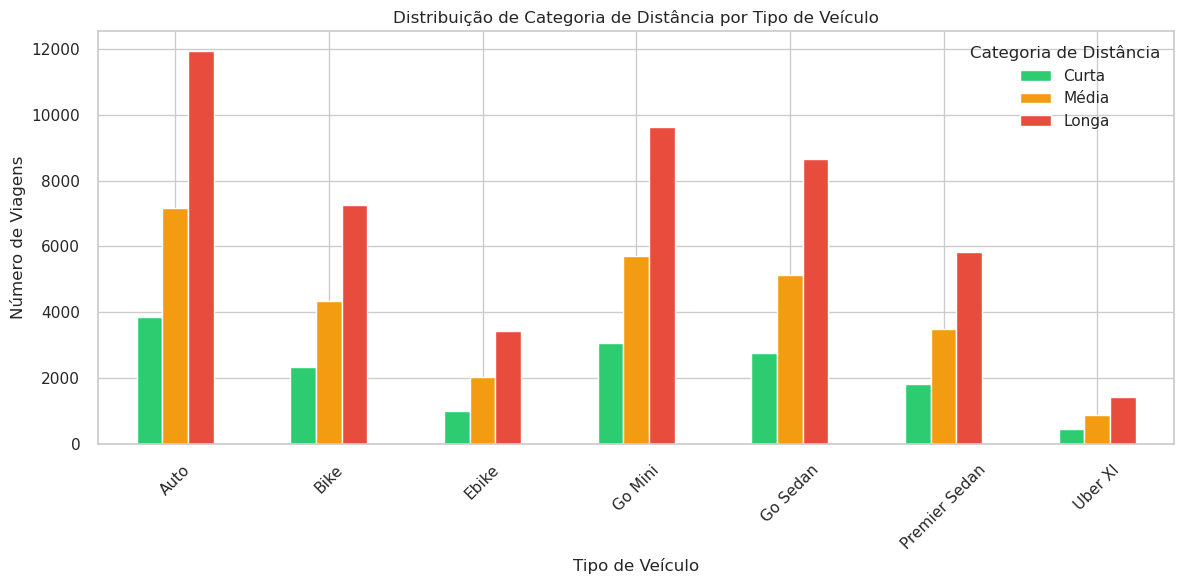

In [18]:
vehicle_distance = df_completed.groupby(['vehicle', 'distance_category']).size().unstack(fill_value=0)

vehicle_distance[category_order].plot(kind='bar', figsize=(12, 6), color=['#2ecc71', '#f39c12', '#e74c3c']), plt.xlabel('Tipo de Veículo')
plt.ylabel('Número de Viagens')
plt.title('Distribuição de Categoria de Distância por Tipo de Veículo')
plt.legend(title='Categoria de Distância')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

<Figure size 1200x600 with 0 Axes>

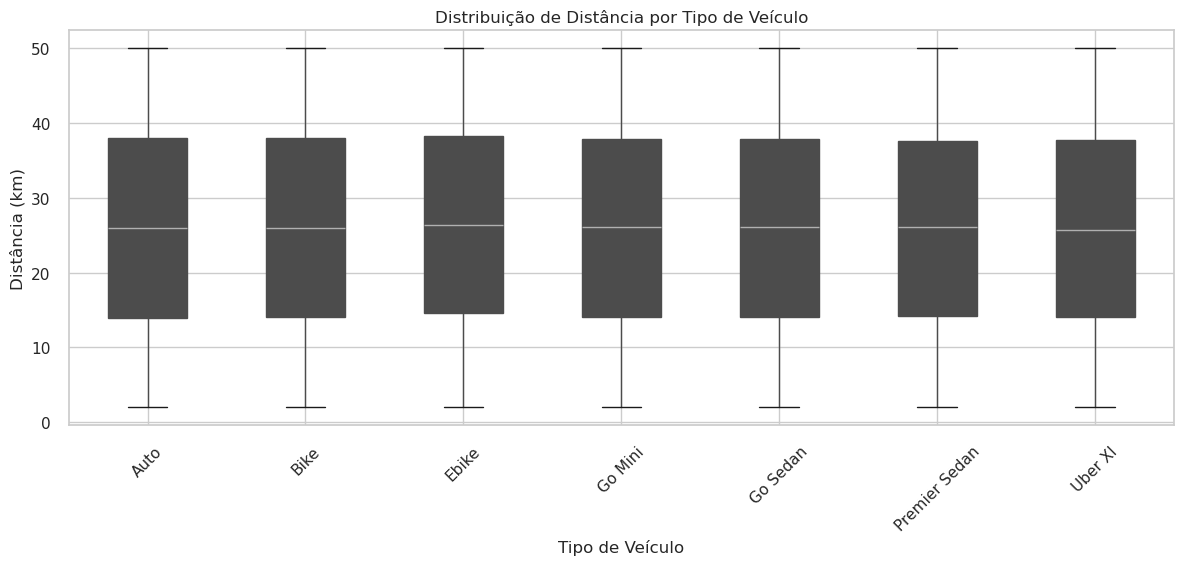

In [19]:
plt.figure(figsize=(12, 6))
df_completed.boxplot(column='distance', by='vehicle', figsize=(12, 6), patch_artist=True)
plt.suptitle('')
plt.xlabel('Tipo de Veículo')
plt.ylabel('Distância (km)')
plt.title('Distribuição de Distância por Tipo de Veículo')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Os gráficos acima nos mostram que a distância média por tipo de veículo é similar entre todos eles, mas podemos ver uma quantidade maior de corridas no geral para veículos do tipo Auto e uma preferência por corridas longas em todos os tipos.

## Análises Temporais

### Padrões Horários

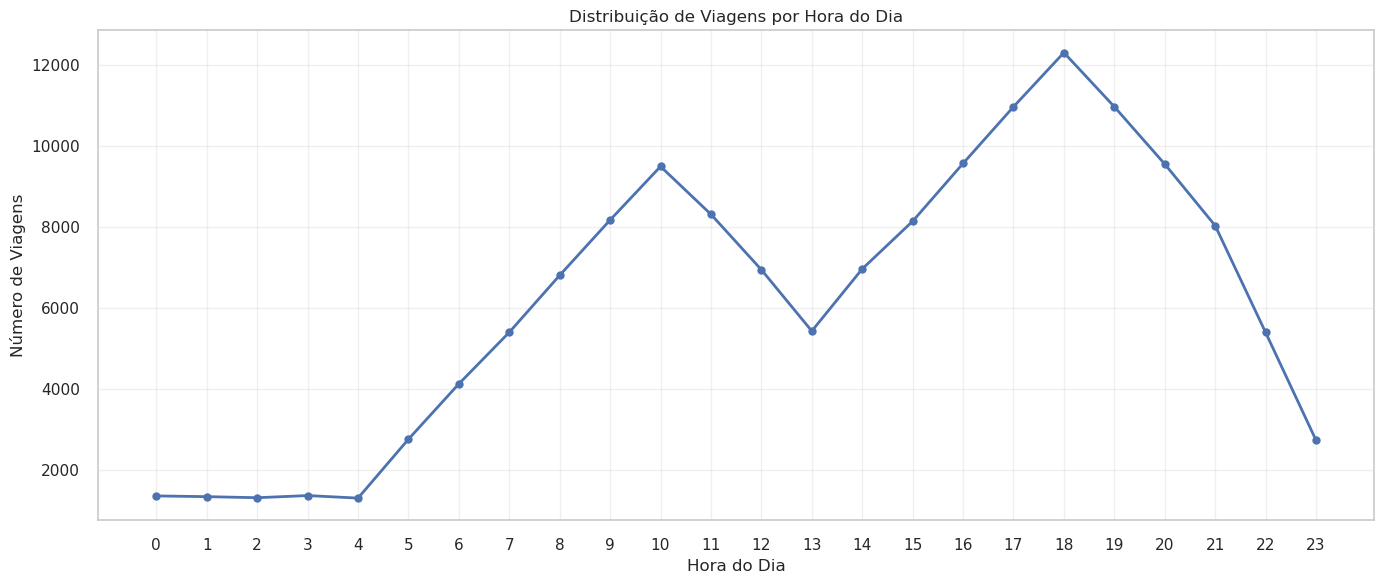

In [20]:
df['hour'] = pd.to_datetime(df['time'], format='%H:%M:%S').dt.hour

hourly_trips = df.groupby('hour').size()

plt.figure(figsize=(14, 6))
plt.plot(hourly_trips.index, hourly_trips.values, marker='o', linewidth=2, markersize=6)
plt.xlabel('Hora do Dia')
plt.ylabel('Número de Viagens')
plt.title('Distribuição de Viagens por Hora do Dia')
plt.xticks(range(0, 24))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [21]:
hourly_stats = df.groupby('hour').agg({
    'id': 'count',
    'value': 'mean',
    'distance': 'mean'
}).round(2)

hourly_stats.columns = ['Total Viagens', 'Receita Média', 'Distância Média']
hourly_stats['Período'] = hourly_stats.index.map(
    lambda x: 'Pico Manhã' if 7 <= x <= 10 else ('Pico Tarde' if 17 <= x <= 20 else 'Normal')
)

print('Top 10 Horários com Mais Viagens:')
hourly_stats.sort_values('Total Viagens', ascending=False).head(10)

Top 10 Horários com Mais Viagens:


,Total Viagens,Receita Média,Distância Média,Período
hour,,,,
18,12298,510.75,24.72,Pico Tarde
19,10963,497.14,24.52,Pico Tarde
17,10962,511.13,24.75,Pico Tarde
16,9565,505.44,24.83,Normal
20,9549,507.55,24.58,Pico Tarde
10,9490,510.74,24.48,Pico Manhã
11,8309,503.98,24.19,Normal
9,8170,516.98,24.71,Pico Manhã
15,8139,507.87,24.67,Normal


Vemos um pico de viagens durante a hora 10, seguido de um vale na hora 13, que aos poucos sobe até um novo pico na hora 18 e cai novamente pela noite e madrugada. Esses picos e vales encaixam muito bem com o horário comercial padrão, indicando um maior fluxo durante o começo do dia aonde todos vão aos seus compromissos, seguido por uma diminuição na demanda por volta do horário de almoço e um fluxo maior novamente ao fim do dia onde a maioria está saindo de seus compromissos.

### Padrões Diários e Semanais

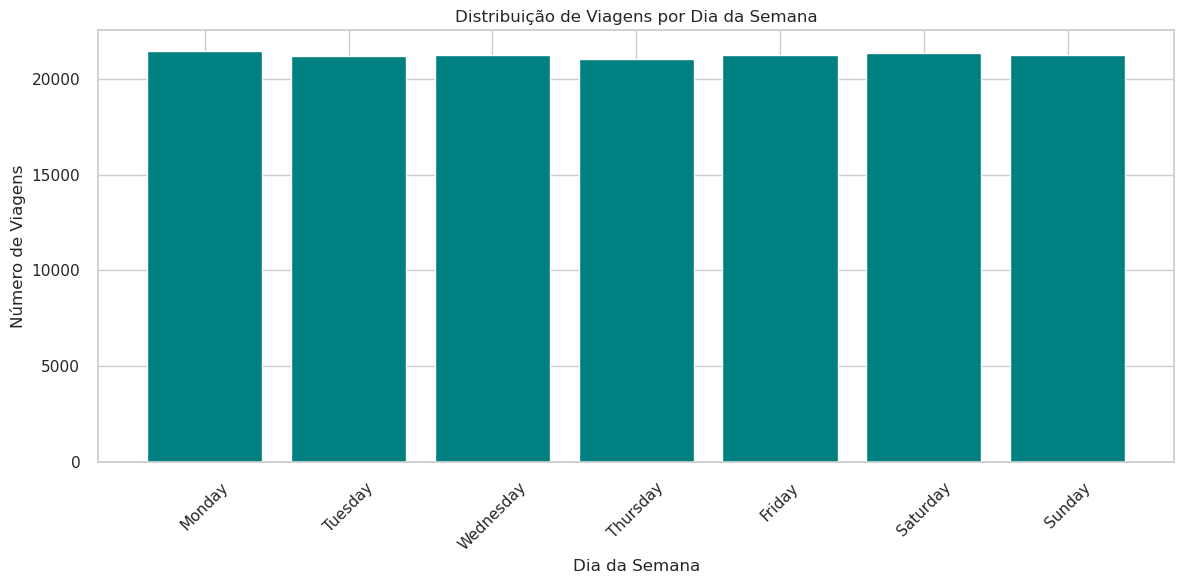

In [22]:
df['date'] = pd.to_datetime(df['date'])
df['day_of_week'] = df['date'].dt.day_name()
df['day_num'] = df['date'].dt.dayofweek

day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
daily_trips = df.groupby('day_of_week').size().reindex(day_order)

plt.figure(figsize=(12, 6))
plt.bar(range(len(daily_trips)), daily_trips.values, color='teal')
plt.xticks(range(len(daily_trips)), daily_trips.index, rotation=45)
plt.xlabel('Dia da Semana')
plt.ylabel('Número de Viagens')
plt.title('Distribuição de Viagens por Dia da Semana')
plt.tight_layout()
plt.show()

A tabela gerada buscou identificar variações nas viagens no decorrer da semana, porém, como apresentado, a variação é baixa, mantendo uma linha quase constante no número de viagens em total.

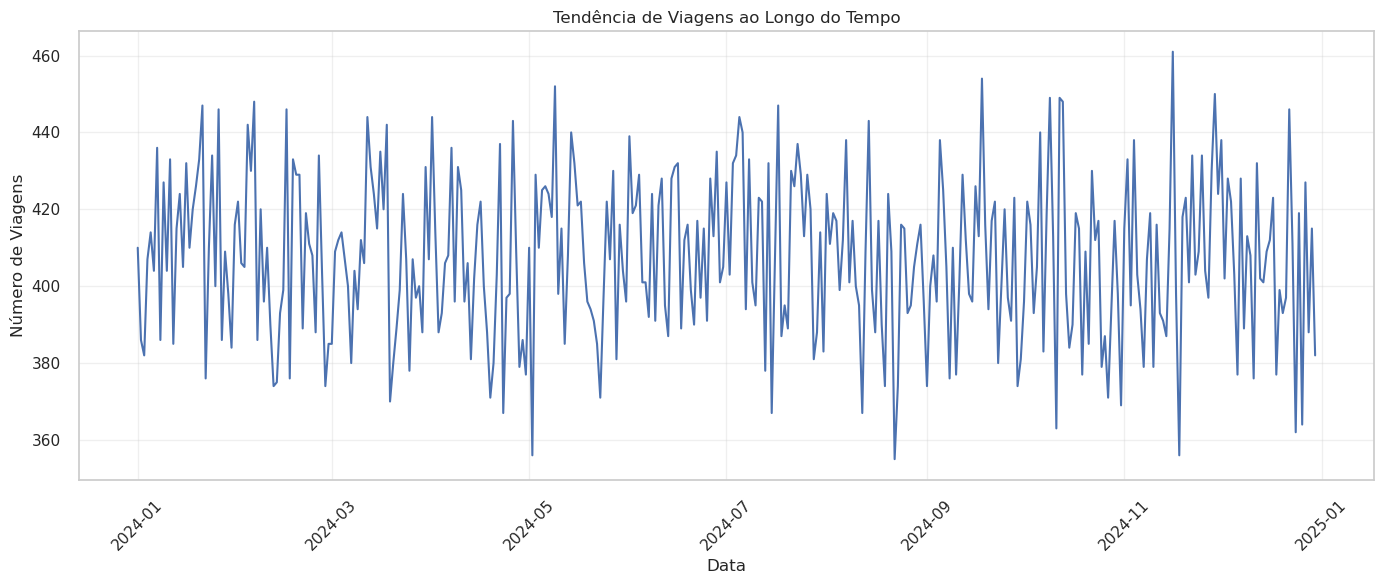

In [23]:
daily_trend = df.groupby('date').size()

plt.figure(figsize=(14, 6))
plt.plot(daily_trend.index, daily_trend.values, linewidth=1.5)
plt.xlabel('Data')
plt.ylabel('Número de Viagens')
plt.title('Tendência de Viagens ao Longo do Tempo')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Vemos alguns picos e vales interressantes que podem indicar datas comemorativas, mas seria preciso uma granularidade maior das datas para termos certeza.

## Análises de Veículos

### Performance por Tipo de Veículo

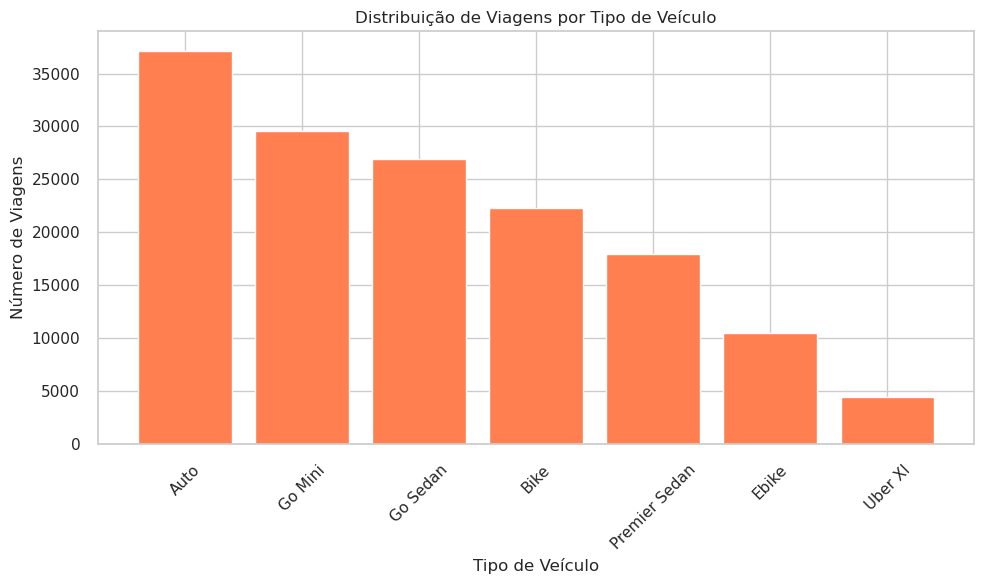

In [24]:
vehicle_counts = df['vehicle'].value_counts()

plt.figure(figsize=(10, 6))
plt.bar(vehicle_counts.index, vehicle_counts.values, color='coral')
plt.xlabel('Tipo de Veículo')
plt.ylabel('Número de Viagens')
plt.title('Distribuição de Viagens por Tipo de Veículo')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [25]:
vehicle_stats = df.groupby('vehicle').agg({
    'id': 'count',
    'status': lambda x: (x == 'Completed').sum() / len(x) * 100,
    'value': 'mean',
    'driver_rating': 'mean'
}).round(2)

vehicle_stats.columns = ['Total Viagens', 'Taxa Conclusão (%)', 'Receita Média', 'Avaliação Média']
vehicle_stats = vehicle_stats.sort_values('Total Viagens', ascending=False)

print('Estatísticas por Tipo de Veículo:')
vehicle_stats

Estatísticas por Tipo de Veículo:


,Total Viagens,Taxa Conclusão (%),Receita Média,Avaliação Média
vehicle,,,,
Auto,37129,61.87,506.79,4.23
Go Mini,29556,62.27,507.78,4.23
Go Sedan,26934,61.45,511.58,4.23
Bike,22318,62.38,509.75,4.23
Premier Sedan,17950,62.16,509.70,4.23
Ebike,10458,61.96,503.93,4.23
Uber Xl,4422,62.53,501.65,4.24


É claro que a maior parte das viagens são feitas pelos veículos Auto, provavelmente pelo custo ser menor, não tão barato quanto tipos Bike por exemplo, mas com um conforto maior e com preços não tão grandes como Uber XI que ficam com o menor número de corridas.

### Veículo vs Zona

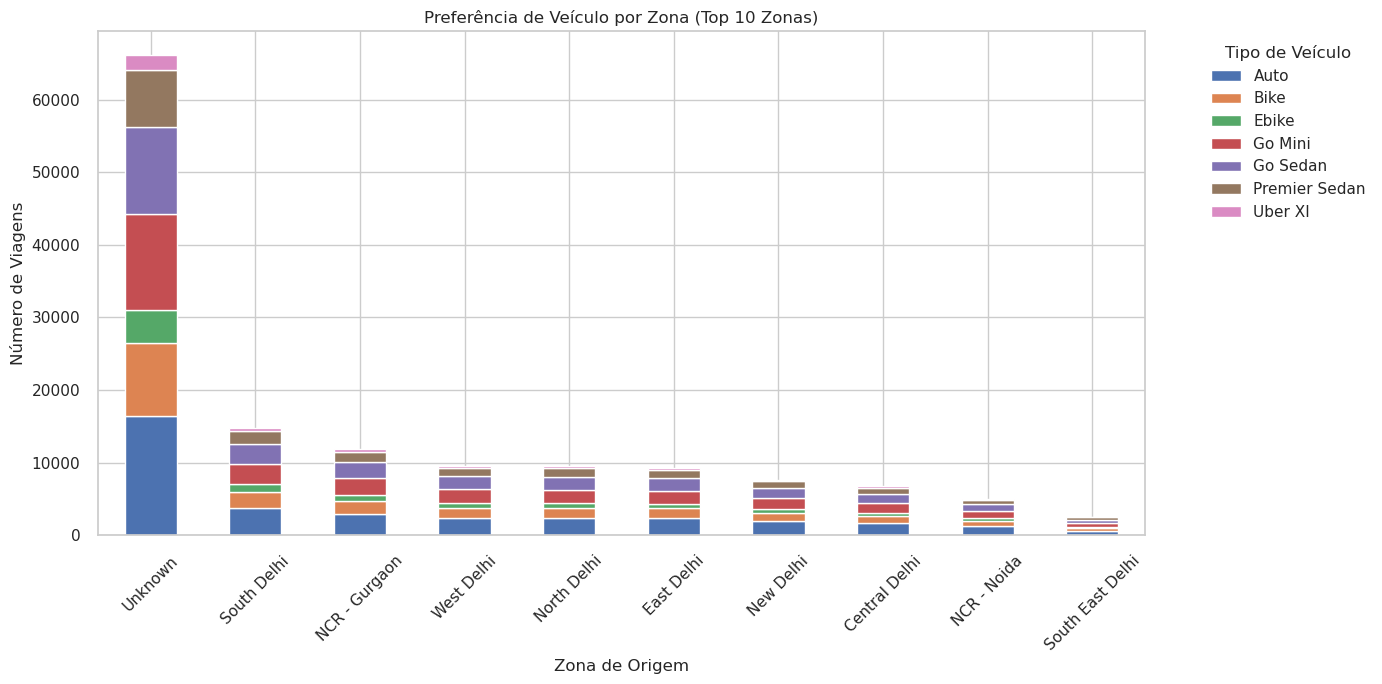

In [26]:
vehicle_zone = df.groupby(['pickup_zone', 'vehicle']).size().unstack(fill_value=0)
top_zones = df['pickup_zone'].value_counts().head(10).index

vehicle_zone.loc[top_zones].plot(kind='bar', stacked=True, figsize=(14, 7))
plt.xlabel('Zona de Origem')
plt.ylabel('Número de Viagens')
plt.title('Preferência de Veículo por Zona (Top 10 Zonas)')
plt.legend(title='Tipo de Veículo', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Análises de Receita

### Receita por Zona

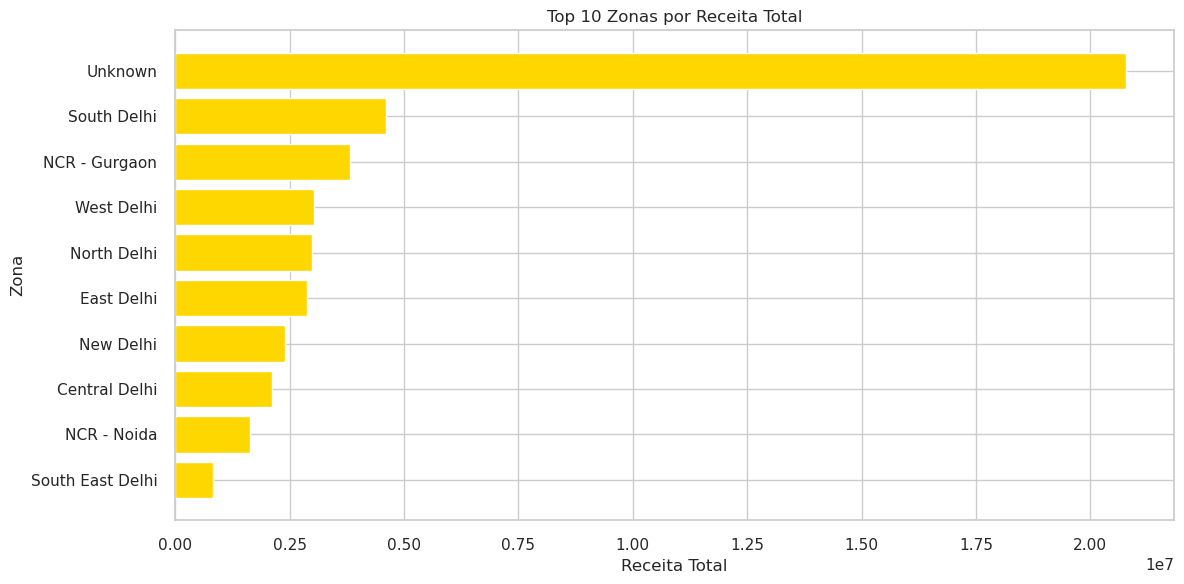

In [27]:
zone_revenue = df_completed.groupby('pickup_zone')['value'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 6))
plt.barh(range(len(zone_revenue)), zone_revenue.values, color='gold')
plt.yticks(range(len(zone_revenue)), zone_revenue.index)
plt.xlabel('Receita Total')
plt.ylabel('Zona')
plt.title('Top 10 Zonas por Receita Total')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

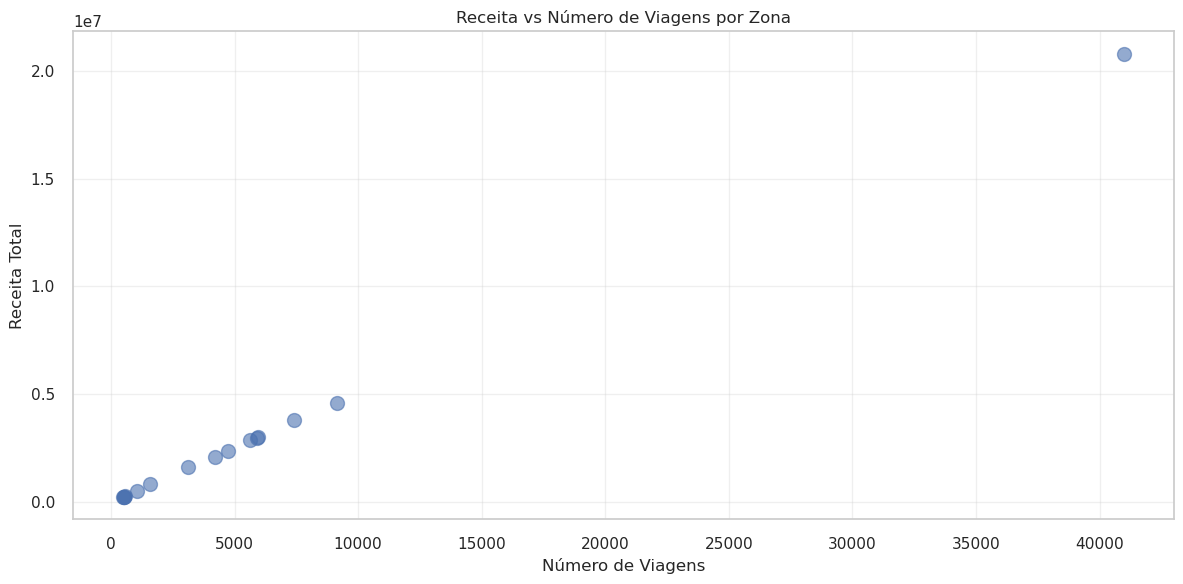

In [28]:
zone_summary = df_completed.groupby('pickup_zone').agg({
    'id': 'count',
    'value': 'sum'
})
zone_summary.columns = ['num_trips', 'total_revenue']

plt.figure(figsize=(12, 6))
plt.scatter(zone_summary['num_trips'], zone_summary['total_revenue'], alpha=0.6, s=100)
plt.xlabel('Número de Viagens')
plt.ylabel('Receita Total')
plt.title('Receita vs Número de Viagens por Zona')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Receita por Categoria de Distância

/run/user/1000/app/org.jupyter.JupyterLab/ipykernel_5240/4185669808.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  category_revenue = df_completed.groupby('distance_category')['value'].sum().reindex(category_order)


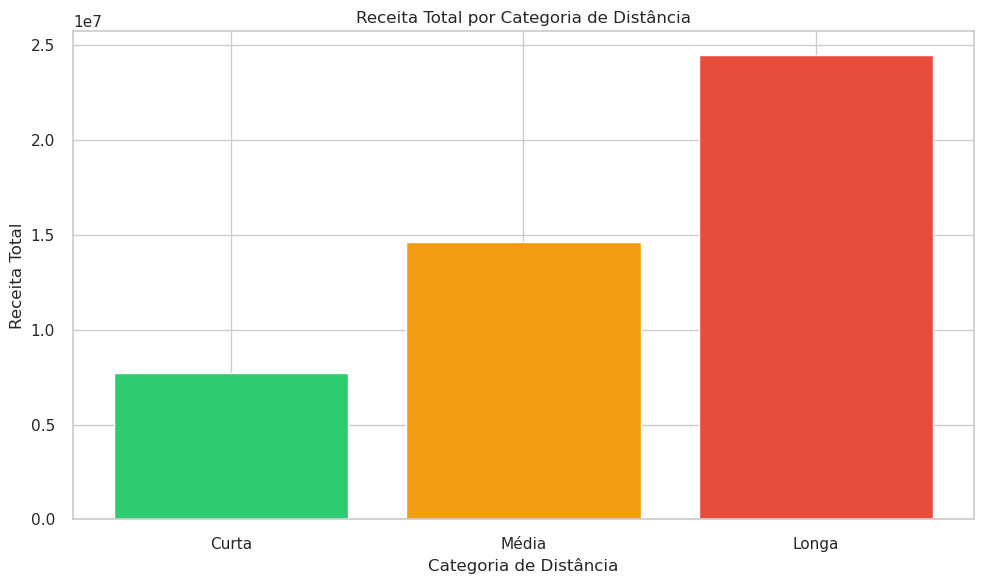

In [29]:
category_revenue = df_completed.groupby('distance_category')['value'].sum().reindex(category_order)

plt.figure(figsize=(10, 6))
plt.bar(category_revenue.index, category_revenue.values, color=['#2ecc71', '#f39c12', '#e74c3c']), plt.xlabel('Categoria de Distância')
plt.ylabel('Receita Total')
plt.title('Receita Total por Categoria de Distância')
plt.tight_layout()
plt.show()

<Figure size 1000x600 with 0 Axes>

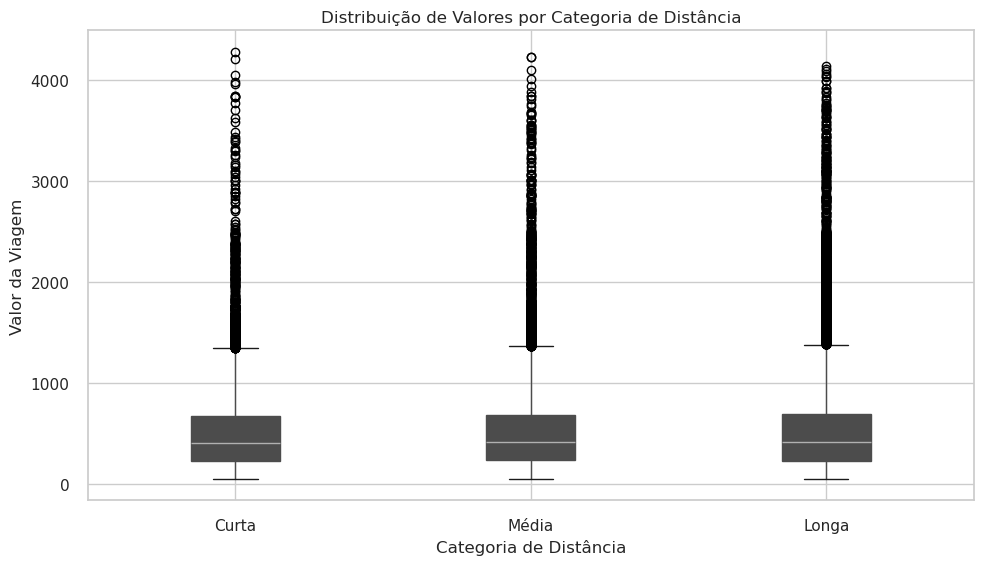

In [30]:
plt.figure(figsize=(10, 6))
df_completed.boxplot(column='value', by='distance_category', figsize=(10, 6), patch_artist=True)
plt.suptitle('')
plt.xlabel('Categoria de Distância')
plt.ylabel('Valor da Viagem')
plt.title('Distribuição de Valores por Categoria de Distância')
plt.tight_layout()
plt.show()

Podemos ver pelo gráfico que as viagens de longa duração possuem uma receita consideravelmente maior que as de curta ou média. Isso possívelmente indica uma preferência dos motoristas por viagens longas que geram maior lucro comparadas às viagens de curta e média distância.

### Análise de Rentabilidade

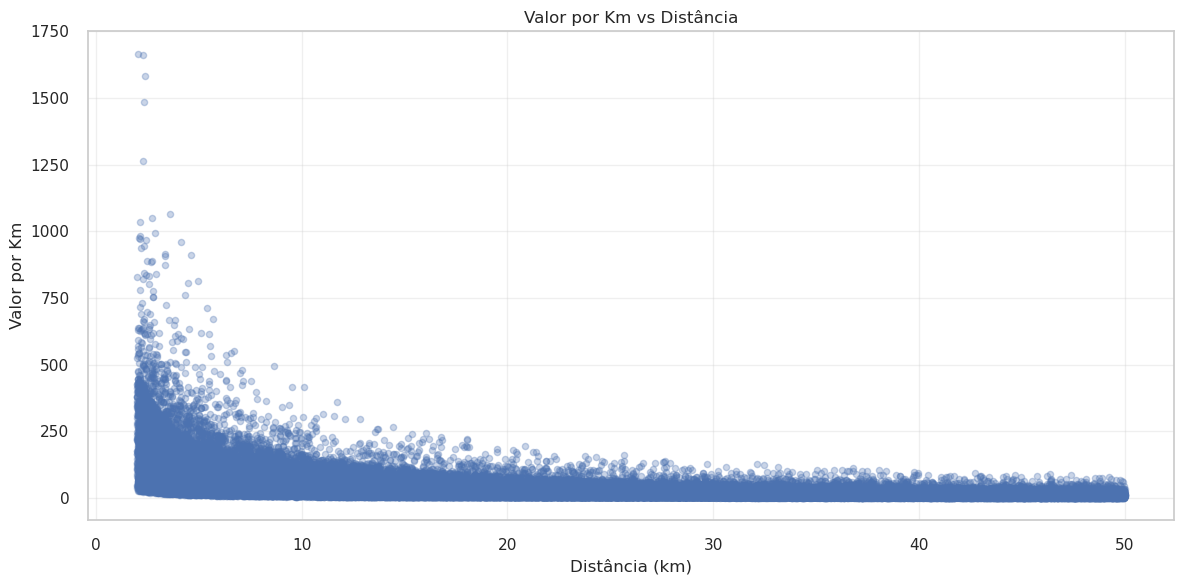

In [31]:
plt.figure(figsize=(12, 6))
plt.scatter(df_value_per_km['distance'], df_value_per_km['value_per_km'], alpha=0.3, s=20)
plt.xlabel('Distância (km)')
plt.ylabel('Valor por Km')
plt.title('Valor por Km vs Distância')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Aqui identificamos algumas viagens que estão muito fora da curva padrão do gráfico, o que indica outliers que podem ser analisados individualmente para tentar compreender o ocorrido a depender da regra de negócio a ser considerada. Mas ignorando os outliers podemos ver uma maior concentração de valores altos nas menores distâncias que vão diminuindo conforme a distância aumenta até chegar em uma média parecida entre 20 a 50km.

In [32]:
zone_profitability = df_value_per_km.groupby('pickup_zone').agg({
    'id': 'count',
    'value_per_km': 'mean'
}).round(2)

zone_profitability.columns = ['Total Viagens', 'Value per Km Médio']
zone_profitability = zone_profitability[zone_profitability['Total Viagens'] >= 50]
zone_profitability = zone_profitability.sort_values('Value per Km Médio', ascending=False)

print('Top 10 Zonas com Melhor Rentabilidade (mínimo 50 viagens):')
zone_profitability.head(10)

Top 10 Zonas com Melhor Rentabilidade (mínimo 50 viagens):


,Total Viagens,Value per Km Médio
pickup_zone,,
NCR - Noida,3120,37.43
North East Delhi,1063,35.31
Airport Zone,555,34.65
NCR - Panipat,510,34.61
East Delhi,5621,34.42
South East Delhi,1589,34.40
NCR - Faridabad,485,34.25
NCR - Gurgaon,7402,34.22
Central Delhi,4193,34.01


## Análises de Status

### Distribuição de Status

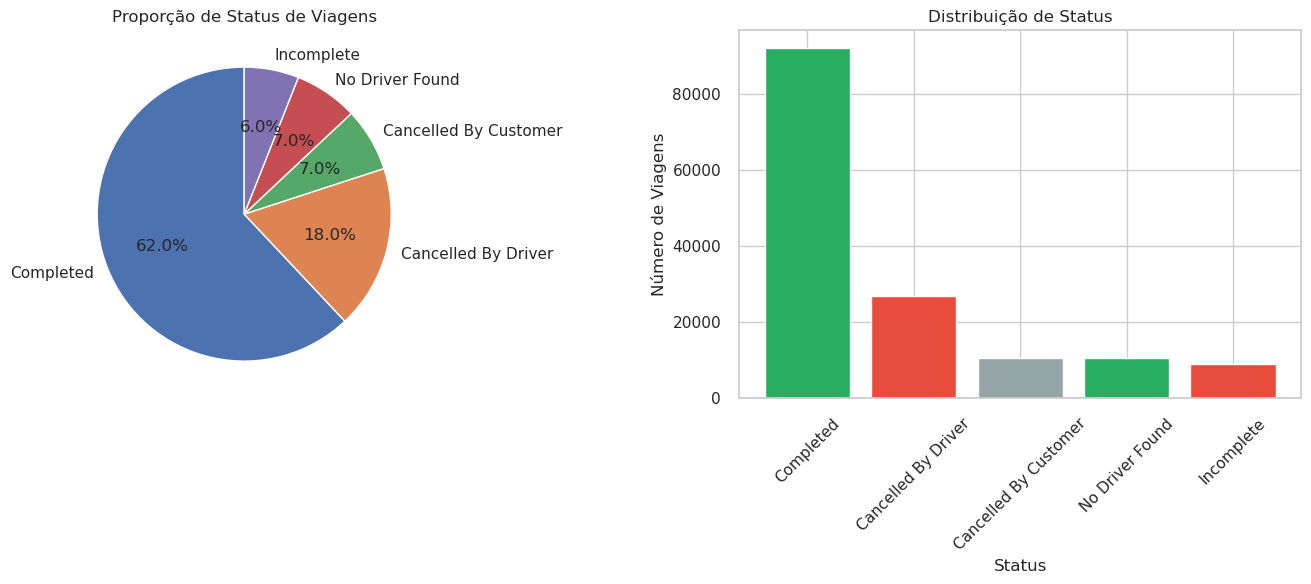

In [33]:
status_counts = df['status'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].pie(status_counts.values, labels=status_counts.index, autopct='%1.1f%%', startangle=90)
axes[0].set_title('Proporção de Status de Viagens')

axes[1].bar(status_counts.index, status_counts.values, color=['#27ae60', '#e74c3c', '#95a5a6']), axes[1].set_xlabel('Status')
axes[1].set_ylabel('Número de Viagens')
axes[1].set_title('Distribuição de Status')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

Podemos ver que a grande maioria das corridas são completas, mas logo em seguida a maioria das corridas canceladas se devem por pedido do próprio motorista.

In [34]:
status_stats = df.groupby('status').agg({
    'id': 'count',
    'value': 'mean',
    'distance': 'mean'
}).round(2)

status_stats.columns = ['Total', 'Receita Média', 'Distância Média']
status_stats['Percentual'] = (status_stats['Total'] / status_stats['Total'].sum() * 100).round(2)

print('Estatísticas por Status:')
status_stats

Estatísticas por Status:


,Total,Receita Média,Distância Média,Percentual
status,,,,
Cancelled By Customer,10402,NaN,NaN,6.99
Cancelled By Driver,26789,NaN,NaN,18.01
Completed,92248,508.19,26.00,62.01
Incomplete,8927,509.34,10.55,6.00
No Driver Found,10401,NaN,NaN,6.99


### Cancelamentos

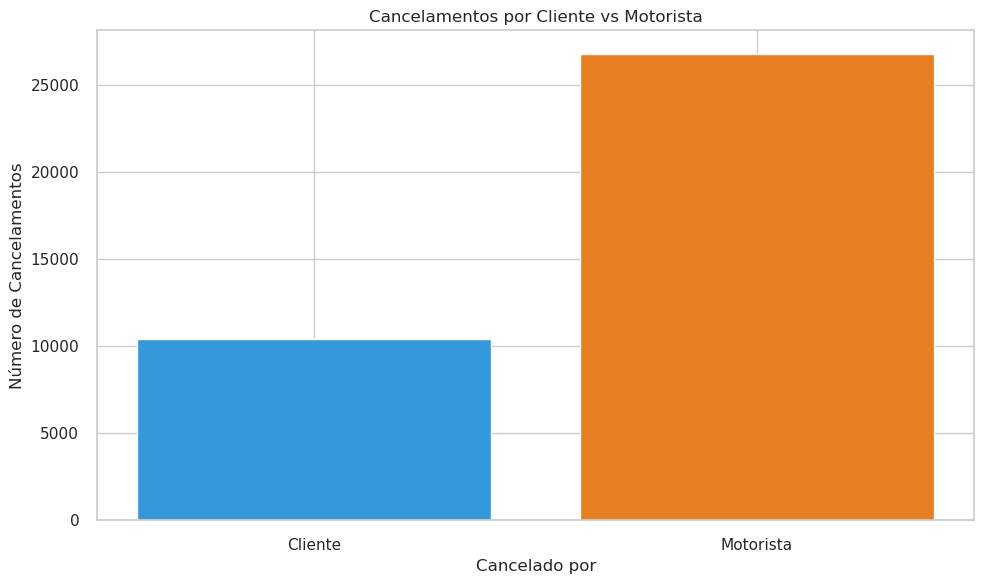

Total de cancelamentos por cliente: 10402
Total de cancelamentos por motorista: 26789
Taxa de cancelamento total: 25.00%


In [35]:
cancelled_by_customer = df['cancelled_by_customer'].sum()
cancelled_by_driver = df['cancelled_by_driver'].sum()

cancellation_data = pd.Series({
    'Cliente': cancelled_by_customer,
    'Motorista': cancelled_by_driver
})

plt.figure(figsize=(10, 6))
plt.bar(cancellation_data.index, cancellation_data.values, color=['#3498db', '#e67e22']), plt.xlabel('Cancelado por')
plt.ylabel('Número de Cancelamentos')
plt.title('Cancelamentos por Cliente vs Motorista')
plt.tight_layout()
plt.show()

print(f'Total de cancelamentos por cliente: {cancelled_by_customer}')
print(f'Total de cancelamentos por motorista: {cancelled_by_driver}')
print(f'Taxa de cancelamento total: {(cancelled_by_customer + cancelled_by_driver) / len(df) * 100:.2f}%')

In [36]:
zone_cancellation = df.groupby('pickup_zone').agg({
    'id': 'count',
    'cancelled_by_customer': 'sum',
    'cancelled_by_driver': 'sum'
})

zone_cancellation['total_cancellations'] = (
    zone_cancellation['cancelled_by_customer'] + zone_cancellation['cancelled_by_driver']
)
zone_cancellation['cancellation_rate'] = (
    zone_cancellation['total_cancellations'] / zone_cancellation['id'] * 100
).round(2)

zone_cancellation = zone_cancellation.sort_values('cancellation_rate', ascending=False)

print('Top 10 Zonas com Maior Taxa de Cancelamento:')
zone_cancellation[['id', 'total_cancellations', 'cancellation_rate']].head(10)

Top 10 Zonas com Maior Taxa de Cancelamento:


,id,total_cancellations,cancellation_rate
pickup_zone,,,
NCR - Faridabad,825,230,27.88
Airport Zone,872,234,26.83
NCR - Ghaziabad,860,230,26.74
East Delhi,9199,2357,25.62
North Delhi,9494,2399,25.27
West Delhi,9543,2398,25.13
New Delhi,7645,1915,25.05
Unknown,66105,16553,25.04
South Delhi,14730,3681,24.99


## Análises de Avaliações

### Distribuição de Avaliações

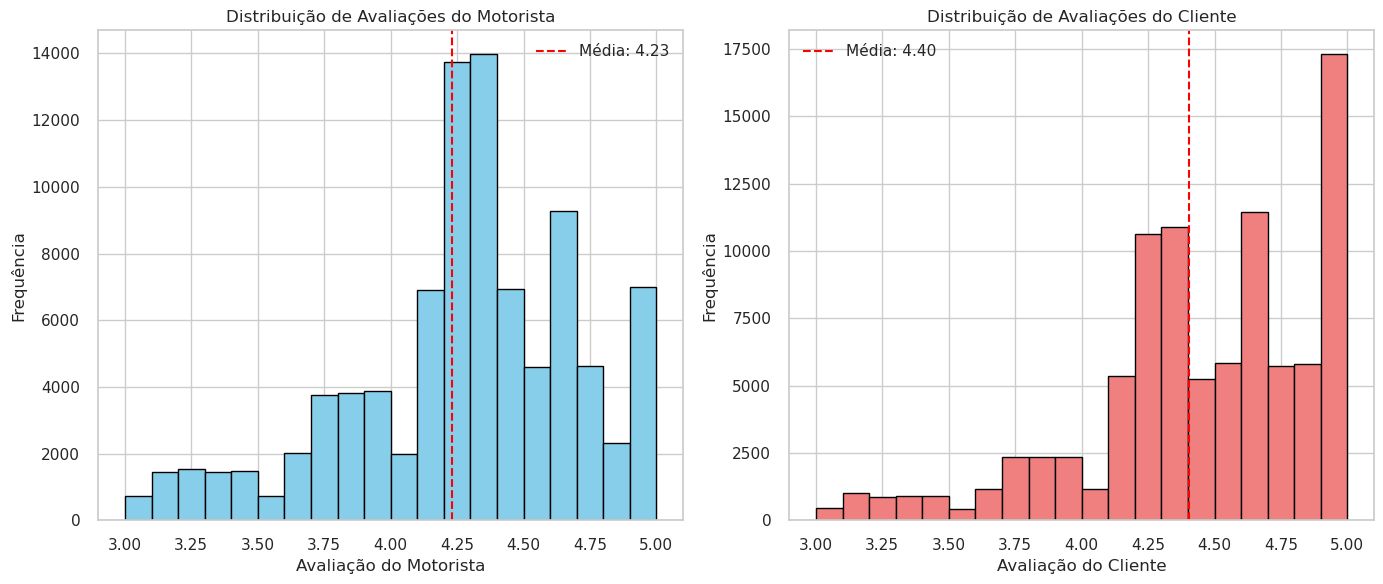

In [37]:
df_rated = df[df['driver_rating'].notna() & df['customer_rating'].notna()]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].hist(df_rated['driver_rating'], bins=20, color='skyblue', edgecolor='black')
axes[0].set_xlabel('Avaliação do Motorista')
axes[0].set_ylabel('Frequência')
axes[0].set_title('Distribuição de Avaliações do Motorista')
axes[0].axvline(df_rated['driver_rating'].mean(), color='red', linestyle='--', 
                label=f'Média: {df_rated["driver_rating"].mean():.2f}')
axes[0].legend()

axes[1].hist(df_rated['customer_rating'], bins=20, color='lightcoral', edgecolor='black')
axes[1].set_xlabel('Avaliação do Cliente')
axes[1].set_ylabel('Frequência')
axes[1].set_title('Distribuição de Avaliações do Cliente')
axes[1].axvline(df_rated['customer_rating'].mean(), color='red', linestyle='--', 
                label=f'Média: {df_rated["customer_rating"].mean():.2f}')
axes[1].legend()

plt.tight_layout()
plt.show()

Vemos no gráfico acima que a avaliação do cliente é normalmente maior do que a do motorista, com a do cliente tendo um pico em 5 enquanto a do motorista tem picos perto de 4.25, contudo a frequência de avaliações também é muito maior para o cliente do para o motorista, indicando que muitas vezes o cliente pula a etapa de avaliação.

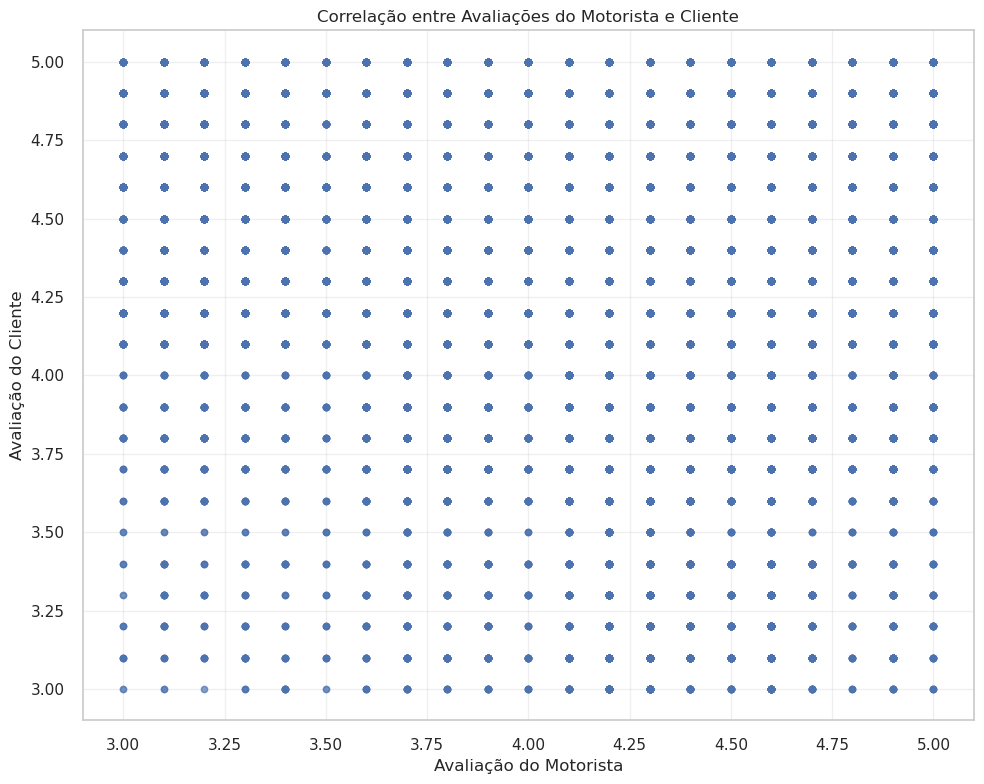

Correlação entre avaliações: -0.001


In [38]:
plt.figure(figsize=(10, 8))
plt.scatter(df_rated['driver_rating'], df_rated['customer_rating'], alpha=0.3, s=20)
plt.xlabel('Avaliação do Motorista')
plt.ylabel('Avaliação do Cliente')
plt.title('Correlação entre Avaliações do Motorista e Cliente')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

correlation = df_rated[['driver_rating', 'customer_rating']].corr().iloc[0, 1]
print(f'Correlação entre avaliações: {correlation:.3f}')

### Avaliações por Zona

In [39]:
zone_ratings = df_rated.groupby('pickup_zone').agg({
    'id': 'count',
    'driver_rating': 'mean',
    'customer_rating': 'mean'
}).round(2)

zone_ratings.columns = ['Total Avaliações', 'Avaliação Motorista Média', 'Avaliação Cliente Média']
zone_ratings = zone_ratings[zone_ratings['Total Avaliações'] >= 50]

print('Top 10 Zonas com Melhores Avaliações de Motorista:')
print(zone_ratings.sort_values('Avaliação Motorista Média', ascending=False).head(10))

print('\nTop 10 Zonas com Piores Avaliações de Motorista:')
print(zone_ratings.sort_values('Avaliação Motorista Média', ascending=True).head(10))

Top 10 Zonas com Melhores Avaliações de Motorista:
                  Total Avaliações  Avaliação Motorista Média  \
pickup_zone                                                     
NCR - Panipat                  510                       4.26   
Central Delhi                 4193                       4.24   
East Delhi                    5621                       4.24   
South Delhi                   9125                       4.24   
North East Delhi              1063                       4.24   
South West Delhi               523                       4.24   
NCR - Gurgaon                 7402                       4.23   
NCR - Ghaziabad                529                       4.23   
New Delhi                     4715                       4.23   
South East Delhi              1589                       4.23   

                  Avaliação Cliente Média  
pickup_zone                                
NCR - Panipat                        4.39  
Central Delhi                       

Vemos uma média de avaliação muito similar entre todas as zonas, indicando não muita diferença por localidade.

## Análises de Pagamento

### Métodos de Pagamento

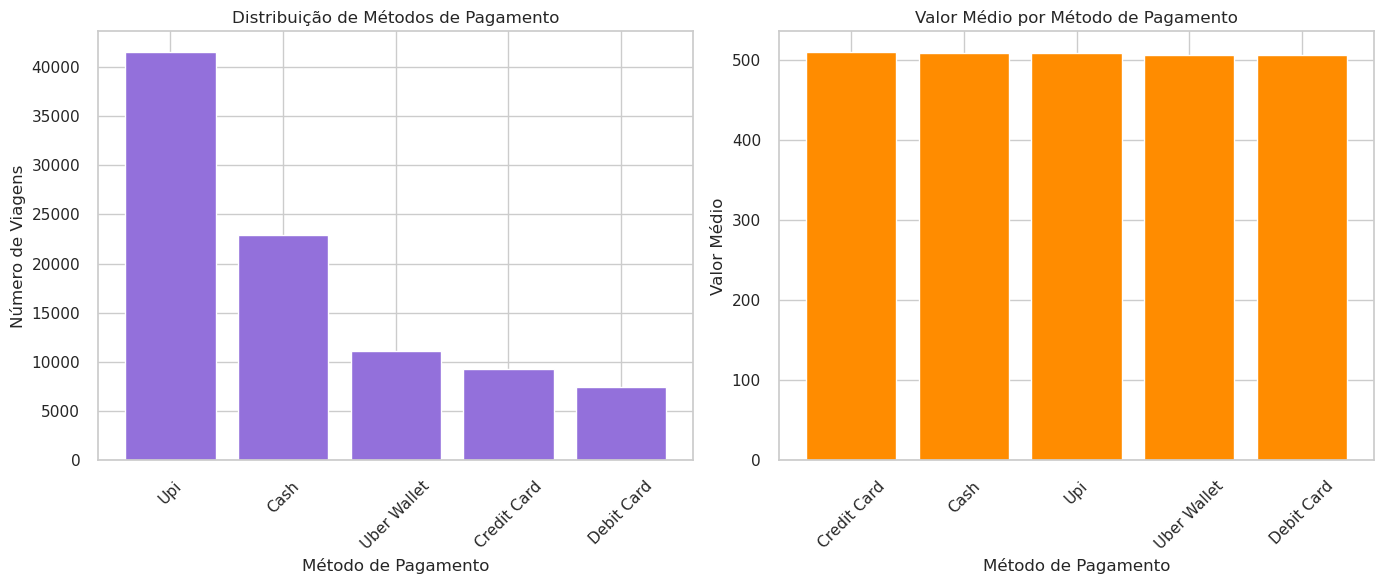

In [40]:
payment_counts = df_completed['payment'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].bar(payment_counts.index, payment_counts.values, color='mediumpurple')
axes[0].set_xlabel('Método de Pagamento')
axes[0].set_ylabel('Número de Viagens')
axes[0].set_title('Distribuição de Métodos de Pagamento')
axes[0].tick_params(axis='x', rotation=45)

payment_avg_value = df_completed.groupby('payment')['value'].mean().sort_values(ascending=False)
axes[1].bar(payment_avg_value.index, payment_avg_value.values, color='darkorange')
axes[1].set_xlabel('Método de Pagamento')
axes[1].set_ylabel('Valor Médio')
axes[1].set_title('Valor Médio por Método de Pagamento')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

O gráfico indica que a maior parte dos pagamentos é feito por Upi e a menor sendo feita por cartão de débito, mas apesar disso, o preço se mantém consistente independente do método de pagamento.

### Pagamento vs Zona

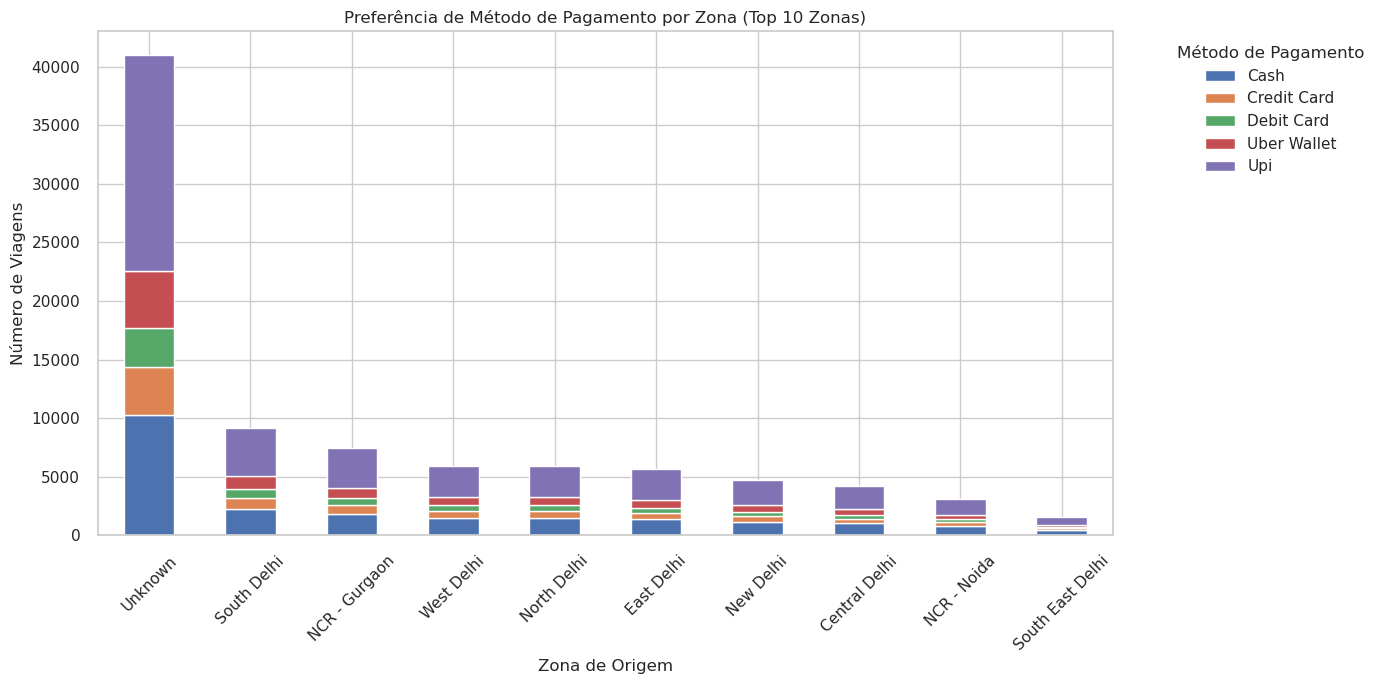

In [41]:
payment_zone = df_completed.groupby(['pickup_zone', 'payment']).size().unstack(fill_value=0)
top_zones_payment = df_completed['pickup_zone'].value_counts().head(10).index

payment_zone.loc[top_zones_payment].plot(kind='bar', stacked=True, figsize=(14, 7))
plt.xlabel('Zona de Origem')
plt.ylabel('Número de Viagens')
plt.title('Preferência de Método de Pagamento por Zona (Top 10 Zonas)')
plt.legend(title='Método de Pagamento', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Análises Cruzadas

### Zona vs Categoria de Distância

/run/user/1000/app/org.jupyter.JupyterLab/ipykernel_5240/3910549551.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  zone_distance_cat = df_completed.groupby(['pickup_zone', 'distance_category']).size().unstack(fill_value=0)


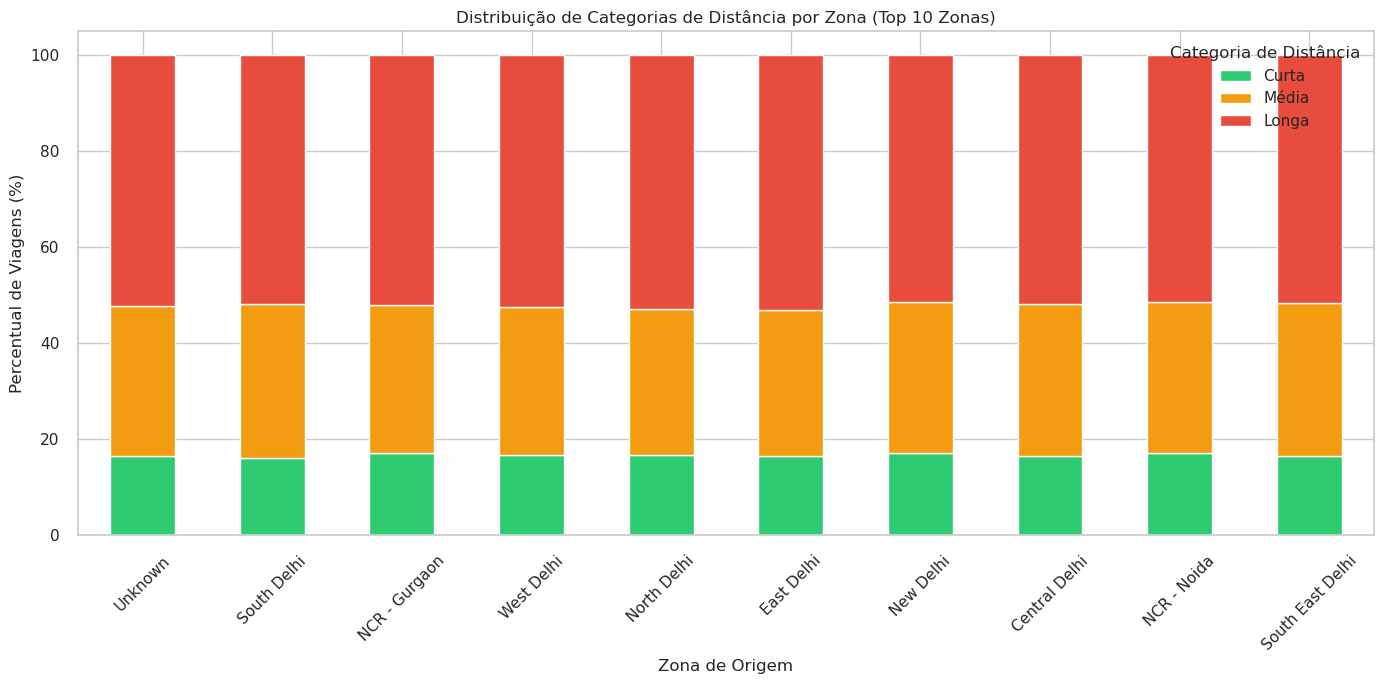

In [42]:
zone_distance_cat = df_completed.groupby(['pickup_zone', 'distance_category']).size().unstack(fill_value=0)
top_zones_cross = df_completed['pickup_zone'].value_counts().head(10).index

zone_distance_cat_pct = zone_distance_cat.div(zone_distance_cat.sum(axis=1), axis=0) * 100

zone_distance_cat_pct.loc[top_zones_cross][category_order].plot(
    kind='bar', stacked=True, figsize=(14, 7),
    color=['#2ecc71', '#f39c12', '#e74c3c'])
plt.xlabel('Zona de Origem')
plt.ylabel('Percentual de Viagens (%)')
plt.title('Distribuição de Categorias de Distância por Zona (Top 10 Zonas)')
plt.legend(title='Categoria de Distância')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [43]:
zone_dominant_category = zone_distance_cat.idxmax(axis=1)
zone_category_summary = pd.DataFrame({
    'Categoria Predominante': zone_dominant_category,
    'Total Viagens': zone_distance_cat.sum(axis=1)
}).sort_values('Total Viagens', ascending=False)

print('Categoria de Distância Predominante por Zona (Top 15):')
zone_category_summary.head(15)

Categoria de Distância Predominante por Zona (Top 15):


,Categoria Predominante,Total Viagens
pickup_zone,,
Unknown,Longa,40986
South Delhi,Longa,9125
NCR - Gurgaon,Longa,7402
West Delhi,Longa,5927
North Delhi,Longa,5905
East Delhi,Longa,5621
New Delhi,Longa,4715
Central Delhi,Longa,4193
NCR - Noida,Longa,3120


Vemos uma predominância muito grande por corridas longas, independente da zona de partida.

### Região vs Tipo de Veículo

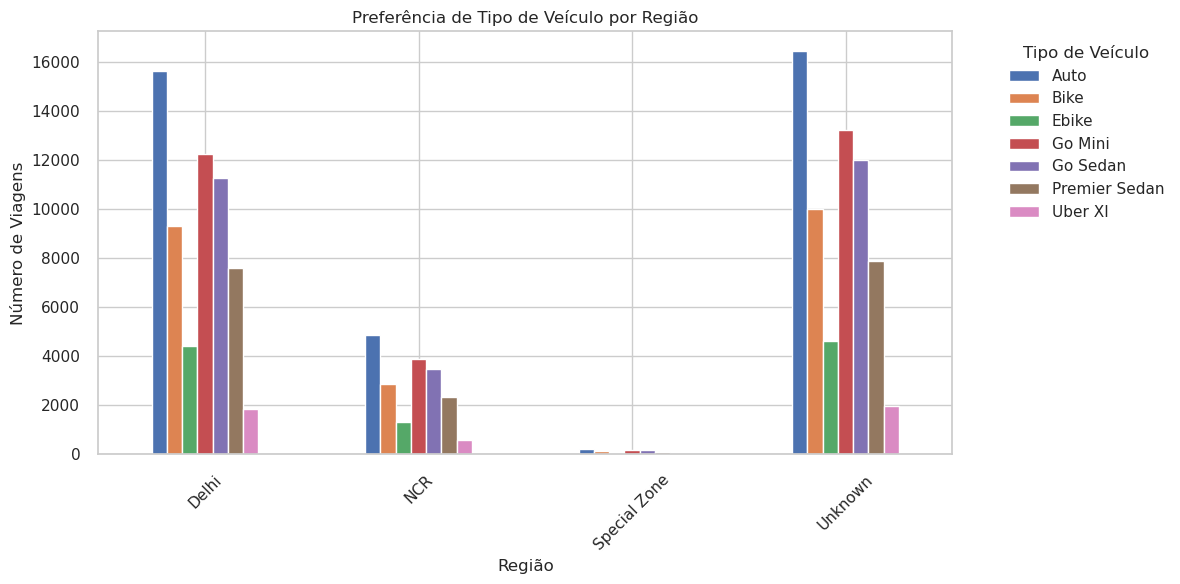

In [44]:
region_vehicle = df.groupby(['pickup_region', 'vehicle']).size().unstack(fill_value=0)

region_vehicle.plot(kind='bar', figsize=(12, 6))
plt.xlabel('Região')
plt.ylabel('Número de Viagens')
plt.title('Preferência de Tipo de Veículo por Região')
plt.legend(title='Tipo de Veículo', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Podemos ver que independente da região o tipo de veículo Auto é predominante na preferência para pedidos de viagem.

### Rentabilidade vs Horário

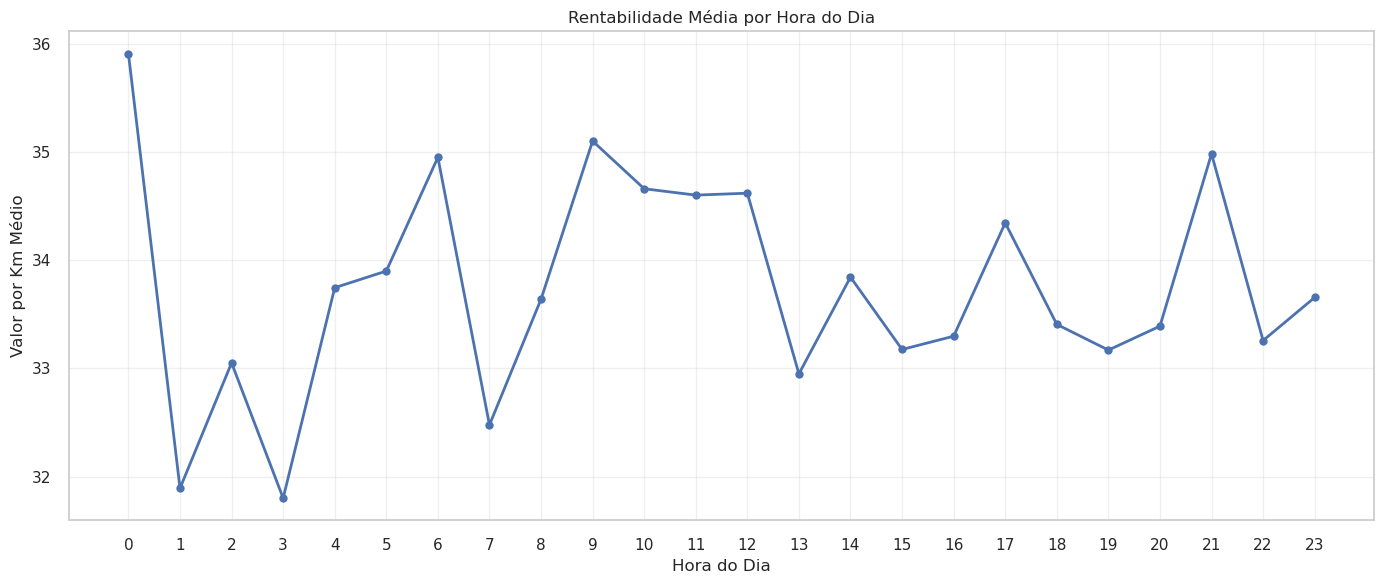

In [45]:
df_value_per_km['hour'] = pd.to_datetime(df_value_per_km['time'], format='%H:%M:%S').dt.hour

hourly_profitability = df_value_per_km.groupby('hour')['value_per_km'].mean()

plt.figure(figsize=(14, 6))
plt.plot(hourly_profitability.index, hourly_profitability.values, marker='o', linewidth=2, markersize=6)
plt.xlabel('Hora do Dia')
plt.ylabel('Valor por Km Médio')
plt.title('Rentabilidade Média por Hora do Dia')
plt.xticks(range(0, 24))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [46]:
hourly_prof_stats = df_value_per_km.groupby('hour').agg({
    'id': 'count',
    'value_per_km': 'mean',
    'value': 'sum'
}).round(2)

hourly_prof_stats.columns = ['Total Viagens', 'Value per Km Médio', 'Receita Total']
hourly_prof_stats = hourly_prof_stats.sort_values('Value per Km Médio', ascending=False)

print('Top 10 Horários Mais Rentáveis:')
hourly_prof_stats.head(10)

Top 10 Horários Mais Rentáveis:


,Total Viagens,Value per Km Médio,Receita Total
hour,,,
0,854,35.91,433573.0
9,5044,35.10,2610648.0
21,5063,34.98,2603159.0
6,2586,34.95,1329133.0
10,5925,34.66,3028536.0
12,4299,34.62,2215047.0
11,5208,34.60,2619029.0
17,6804,34.35,3493698.0
5,1705,33.90,851692.0


Podemos ver que a hora mais rentável é à meia noite, provavelmete pelo número menor de motoristas, assim levando à um aumento no preço médio das corridas.

## Encerramento

### Fechar Conexão

In [47]:
conn.close()
print('Conexão com o banco de dados encerrada.')

Conexão com o banco de dados encerrada.
